# KNP POI Merge

In this notebook, SHP files provided by SANParks that contain various KNP POIs are loaded, cleaned, merged, and transferred to a CSV and GeoJSON output file.

The following datasets are provided:

| Dataset             | Processed  |
|---------------------|:----------:|
| Birdhides           | &check;    |
| Camps               | &check;    |
| Dams                | &#10005;   |
| Gates               | &check;    |
| Rivers              | &#10005;   |
| Skukuza Airport     | &#10005;   |
| Solomon et al. 1999 | &#10005;   |
| Tourist sites       | &check;    |
| Waterpoints         | &check;    |

In [239]:
import pandas as pd
from pandas import Series

# prevent false warning
# https://stackoverflow.com/questions/20625582/how-to-deal-with-settingwithcopywarning-in-pandas
pd.options.mode.chained_assignment = None  # default='warn'

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

import geopandas as gdf

In [240]:
# Access types
PUBLIC: str = 'Public'
PRIVATE: str = 'Private'
STAFF: str = 'Staff'

# Column names
NAME: str = 'Name'
TYPE: str = 'Type'
ACCESS: str = 'Access'
GEOMETRY: str = 'Geometry'

## Birdhides

In [241]:
gdf_birdhides = gdf.read_file('Birdhides.shp')
gdf_birdhides = gdf_birdhides.to_crs(epsg=4326)

In [242]:
gdf_birdhides.head()

,Name,Name_Alias,Lat_DD,Long_DD,geometry
0,Nthandanyathi Bird Hide,Nthandanyathi,-25.207329,31.959580,POINT (31.95958 -25.20733)
1,Lake Panic Bird Hide,Lake Panic,-24.981318,31.566089,POINT (31.56609 -24.98132)
2,Sweni Bird Hide,Sweni,-24.473604,31.973105,POINT (31.97311 -24.47360)
3,Ratel Pan Bird Hide,Ratel Pan,-24.242064,31.642755,POINT (31.64276 -24.24206)
4,Sable Dam Bird Hide,Sable Dam,-23.939594,31.239261,POINT (31.23926 -23.93959)


In [243]:
gdf_birdhides[TYPE] = 'Bird hide'
gdf_birdhides[ACCESS] = PUBLIC  # ?
gdf_birdhides.drop(['Name', 'Lat_DD', 'Long_DD'], axis=1, inplace=True)
gdf_birdhides.rename(columns={
    'Name_Alias': NAME,
    'geometry': GEOMETRY
}, inplace=True)

In [244]:
gdf_birdhides.head()

,Name,Geometry,Type,Access
0,Nthandanyathi,POINT (31.95958 -25.20733),Bird hide,Public
1,Lake Panic,POINT (31.56609 -24.98132),Bird hide,Public
2,Sweni,POINT (31.97311 -24.47360),Bird hide,Public
3,Ratel Pan,POINT (31.64276 -24.24206),Bird hide,Public
4,Sable Dam,POINT (31.23926 -23.93959),Bird hide,Public


In [245]:
birdhides_duplicates: Series = gdf_birdhides.duplicated(subset=['Name'], keep='first').value_counts()

if True in birdhides_duplicates:
    birdhides_duplicate_count: int = birdhides_duplicates[True]
    gdf_birdhides.drop_duplicates(subset=['Name'], inplace=True)
    print(f"{birdhides_duplicate_count} duplicates removed from birdhides dataset.")
else:
    print("No duplicates in birdhides dataset.")

No duplicates in birdhides dataset.


## Camps

In [246]:
gdf_camps = gdf.read_file('camps_all.shp')
gdf_camps = gdf_camps.to_crs(epsg=4326)

In [247]:
gdf_camps.head()

,NAME,DESCRIPT,BOREHOLE,OPERATIONL,SYNONYM,ACCESS,TYPE,geometry
0,Bateleur,NaN,Y,Y,NaN,Public,Bushveld camp,POINT (31.20136 -23.23343)
1,Berg-en-Dal,NaN,N,Y,NaN,Public,Rest camp,POINT (31.44432 -25.42813)
2,Biyamiti,NaN,Y,Y,NaN,Public,Bushveld camp,POINT (31.71035 -25.30811)
3,Boulders,NaN,Y,Y,NaN,Private,Bush Lodge,POINT (31.37501 -23.60793)
4,Crocodile Bridge,NaN,N,Y,NaN,Public,Rest camp,POINT (31.89330 -25.35823)


In [248]:
gdf_camps['ACCESS'].value_counts()

Private    53
Staff      23
Public     22
Name: ACCESS, dtype: int64

In [249]:
gdf_camps['TYPE'].value_counts()

Concession camp         29
Rest camp               12
Ranger camp             11
Staff Accommodation     11
Trails camp              8
Bushveld camp            5
Satellite camp           5
SANDF Base               5
Bush Lodge               3
Unspecified              3
HR camp                  2
Backpack camp            1
Kennels/ K9 training     1
4X4 Camp                 1
EE Centre                1
Name: TYPE, dtype: int64

In [250]:
gdf_camps.replace({'BOREHOLE': {'Y': True, 'N': False}}, inplace=True)
gdf_camps.replace({'OPERATIONL': {'Y': True, 'N': False}}, inplace=True)

gdf_camps.rename(columns={
    'NAME': NAME,
    'DESCRIPT': 'Description',
    'BOREHOLE': 'Borehole',
    'OPERATIONL': 'Operational',
    'SYNONYM': 'Synonym',
    'ACCESS': ACCESS,
    'TYPE': TYPE,
    'geometry': GEOMETRY
}, inplace=True)
gdf_camps.drop(['Description', 'Borehole', 'Operational', 'Synonym'], axis=1, inplace=True)

In [251]:
gdf_camps.head()

,Name,Access,Type,Geometry
0,Bateleur,Public,Bushveld camp,POINT (31.20136 -23.23343)
1,Berg-en-Dal,Public,Rest camp,POINT (31.44432 -25.42813)
2,Biyamiti,Public,Bushveld camp,POINT (31.71035 -25.30811)
3,Boulders,Private,Bush Lodge,POINT (31.37501 -23.60793)
4,Crocodile Bridge,Public,Rest camp,POINT (31.89330 -25.35823)


In [252]:
camps_duplicates: Series = gdf_camps.duplicated(subset=['Name'], keep='first').value_counts()

if True in camps_duplicates:
    camps_duplicate_count: int = birdhides_duplicates[True]
    gdf_camps.drop_duplicates(subset=['Name'], inplace=True)
    print(f"{camps_duplicate_count} duplicates removed from camps dataset.")
else:
    print("No duplicates in camps dataset.")

No duplicates in camps dataset.


## Gates

In [253]:
gdf_gates = gdf.read_file('gates_public.shp')
gdf_gates = gdf_gates.to_crs(epsg=4326)

In [254]:
gdf_gates.head()

,OBJECTID,NAME,TYPE,Access,Lat_DD,Long_DD,geometry
0,1,Crocodile Bridge,KNP Gate,Public,-25.358481,31.892587,POINT (31.89259 -25.35848)
1,2,Malelane,KNP Gate,Public,-25.462242,31.532248,POINT (31.53225 -25.46224)
2,4,Numbi,KNP Gate,Public,-25.155235,31.197791,POINT (31.19779 -25.15524)
3,5,Pafuri,KNP Gate,Public,-22.399849,31.041282,POINT (31.04128 -22.39985)
4,6,Phalaborwa,KNP Gate,Public,-23.945703,31.166062,POINT (31.16606 -23.94570)


In [255]:
gdf_gates['Access'].value_counts()

Public     12
Private     1
Name: Access, dtype: int64

In [256]:
gdf_gates['TYPE'].value_counts()

KNP Gate         10
Port of Entry     2
Private Gate      1
Name: TYPE, dtype: int64

In [257]:
gdf_gates.rename(columns={'OBJECTID': 'ObjectID', 'NAME': NAME, 'TYPE': TYPE, 'geometry': GEOMETRY}, inplace=True)
gdf_gates.drop(['ObjectID', 'Lat_DD', 'Long_DD'], axis=1, inplace=True)

In [258]:
gdf_gates.head()

,Name,Type,Access,Geometry
0,Crocodile Bridge,KNP Gate,Public,POINT (31.89259 -25.35848)
1,Malelane,KNP Gate,Public,POINT (31.53225 -25.46224)
2,Numbi,KNP Gate,Public,POINT (31.19779 -25.15524)
3,Pafuri,KNP Gate,Public,POINT (31.04128 -22.39985)
4,Phalaborwa,KNP Gate,Public,POINT (31.16606 -23.94570)


In [259]:
gates_duplicates: Series = gdf_gates.duplicated(subset=['Name'], keep='first').value_counts()

if True in gates_duplicates:
    gates_duplicate_count: int = sites_duplicates[True]
    gdf_gates.drop_duplicates(subset=['Name'], inplace=True)
    print(f"{gates_duplicate_count} duplicates removed from gates dataset.")
else:
    print("No duplicates in gates dataset.")

No duplicates in gates dataset.


## Tourist sites

In [260]:
gdf_sites = gdf.read_file('tourist_sites.shp')
gdf_sites = gdf_sites.to_crs(epsg=4326)

In [261]:
gdf_sites.head()

,OBJECTID,NAME,DESCRIPT,SYNONYM,BOREHOLE,PICNICSITE,GET_OUT,LOOK_OUT,WATERHOLE,DAM,KOP,RUIN,TYPE,geometry
0,1,Afsaal,Picnic spot,NaN,1,1,0,0,0,0,0,0,Picnic spot,POINT (31.53270 -25.28679)
1,2,Mooiplaas,Picnic spot,Mooi Plaas,1,1,0,0,0,0,0,0,Picnic spot,POINT (31.44098 -23.55588)
2,3,Muzandzeni,Picnic spot,Mzanzene,1,1,0,0,0,0,0,0,Picnic spot,POINT (31.63474 -24.48167)
3,4,Nkuhlu,Picnic spot,NaN,0,1,0,0,0,0,0,0,Picnic spot,POINT (31.76912 -24.99692)
4,5,Pafuri,Picnic spot,NaN,0,1,0,0,0,0,0,0,Picnic spot,POINT (31.24739 -22.42276)


In [262]:
gdf_sites['TYPE'].value_counts()

Picnic spot       14
Get out point     13
Look out point    13
Day visitor        8
Dam                5
Pan                1
Name: TYPE, dtype: int64

In [263]:
gdf_sites['BOREHOLE'] = gdf_sites['BOREHOLE'].astype(bool)
gdf_sites['PICNICSITE'] = gdf_sites['PICNICSITE'].astype(bool)
gdf_sites['GET_OUT'] = gdf_sites['GET_OUT'].astype(bool)
gdf_sites['LOOK_OUT'] = gdf_sites['LOOK_OUT'].astype(bool)
gdf_sites['WATERHOLE'] = gdf_sites['WATERHOLE'].astype(bool)
gdf_sites['DAM'] = gdf_sites['DAM'].astype(bool)
gdf_sites['KOP'] = gdf_sites['KOP'].astype(bool)
gdf_sites['RUIN'] = gdf_sites['RUIN'].astype(bool)

In [264]:
gdf_sites.head()

,OBJECTID,NAME,DESCRIPT,SYNONYM,BOREHOLE,PICNICSITE,GET_OUT,LOOK_OUT,WATERHOLE,DAM,KOP,RUIN,TYPE,geometry
0,1,Afsaal,Picnic spot,NaN,True,True,False,False,False,False,False,False,Picnic spot,POINT (31.53270 -25.28679)
1,2,Mooiplaas,Picnic spot,Mooi Plaas,True,True,False,False,False,False,False,False,Picnic spot,POINT (31.44098 -23.55588)
2,3,Muzandzeni,Picnic spot,Mzanzene,True,True,False,False,False,False,False,False,Picnic spot,POINT (31.63474 -24.48167)
3,4,Nkuhlu,Picnic spot,NaN,False,True,False,False,False,False,False,False,Picnic spot,POINT (31.76912 -24.99692)
4,5,Pafuri,Picnic spot,NaN,False,True,False,False,False,False,False,False,Picnic spot,POINT (31.24739 -22.42276)


In [265]:
gdf_sites.rename(columns={
    'OBJECTID': 'ObjectID',
    'NAME': NAME,
    'DESCRIPT': 'Description',
    'SYNONYM': 'Synonym',
    'BOREHOLE': 'Borehole',
    'PICNICSITE': 'Picnic_Site',
    'GET_OUT': 'Get_Out',
    'LOOK_OUT': 'Look_Out',
    'WATERHOLE': 'Waterhole',
    'DAM': 'Dam',
    'KOP': 'Kop',
    'RUIN': 'Ruin',
    'TYPE': TYPE,
    'geometry': GEOMETRY
}, inplace=True)
gdf_sites.drop(['ObjectID', 'Description', 'Synonym', 'Borehole', 'Picnic_Site', 'Get_Out', 'Look_Out', 'Waterhole', 'Dam', 'Kop', 'Ruin'], axis=1, inplace=True)

In [266]:
gdf_sites[ACCESS] = PUBLIC  # ?

In [267]:
gdf_sites.head()

,Name,Type,Geometry,Access
0,Afsaal,Picnic spot,POINT (31.53270 -25.28679),Public
1,Mooiplaas,Picnic spot,POINT (31.44098 -23.55588),Public
2,Muzandzeni,Picnic spot,POINT (31.63474 -24.48167),Public
3,Nkuhlu,Picnic spot,POINT (31.76912 -24.99692),Public
4,Pafuri,Picnic spot,POINT (31.24739 -22.42276),Public


In [268]:
sites_duplicates: Series = gdf_sites.duplicated(subset=['Name'], keep='first').value_counts()

if True in sites_duplicates:
    sites_duplicate_count: int = sites_duplicates[True]
    gdf_sites.drop_duplicates(subset=['Name'], inplace=True)
    print(f"{sites_duplicate_count} duplicates removed from sites dataset.")
else:
    print("No duplicates in sites dataset.")

No duplicates in sites dataset.


## Waterpoints

In [269]:
gdf_waterpoints = gdf.read_file('Waterpoints_zambatis_2016.shp')
gdf_waterpoints = gdf_waterpoints.to_crs(epsg=4326)

In [270]:
gdf_waterpoints.head()

,NAME,TYPE,RANGER_SEC,HOLE_DRILL,BOREHOLE_D,BOREHOLE_1,STRUCTURES,PURPOSE,STATUS___S,REHABILITA,LOCALITY,Y_COORD,X_COORD,NOTES___CO,Label,Lable_Name,Label_Type,geometry
0,Afsaal,Borehole,MAL,1983,60/5,5450,SRT,D,O-RO,N/A,Afsaal picnic site,-25.28517,31.53319,NaN,Open,Afsaal,Borehole,POINT (31.53319 -25.28517)
1,Ampie,Borehole,MAL,c1973,31/8,1703,SRT,W,O-RO,N/A,13 km NNE Malelane,-25.35544,31.52741,NaN,Open,Ampie,Borehole,POINT (31.52741 -25.35544)
2,Babalala,Boreholes (2),VLA,?,11/-,1514,S,W & D,DRT & D,N/A,5 km SSE Vlakteplaas,-22.90582,31.24928,"Two boreholes at Babalala, providing water for...",Drought,Babalala,Borehole,POINT (31.24928 -22.90582)
3,Babalala,Boreholes (2),VLA,?,30/1,14985,S,W & D,DRT & D,N/A,5 km SSE Vlakteplaas,-22.90582,31.24928,"Two boreholes at Babalala, providing water for...",Drought,Babalala,Borehole,POINT (31.24928 -22.90582)
4,Balule,Borehole,HOU,?,85/-,5678,D,D,O-RO,N/A,6 km S Olifants,-24.05454,31.73373,NaN,Open,Balule,Borehole,POINT (31.73373 -24.05454)


In [271]:
gdf_waterpoints['TYPE'].value_counts()

Borehole                        42
Dam, earthen                    19
Borehole No. 1                  14
Borehole No. 2                  14
Dam, concrete                   12
Pipeline trough                  6
Dam, concrete weir               6
Borehole No. 1 N                 4
Borehole No. 3                   3
Borehole No. 1 SW                3
Borehole No. 2 E                 3
Borehole No. 2 S                 2
Boreholes (2)                    2
Borehole No. 2 SE                2
Borehole No. 1 SE                2
Borehole No. 1 W                 2
Borehole S                       2
Borehole No. 3 W                 1
Borehole No. 2 >w                1
Borehole E-48                    1
Borehole No. 2 W                 1
Borehole N                       1
Borehole WSW                     1
Borehole No. 1 E                 1
Borehole N-75                    1
Borehole No. 2 SSE-150           1
Borehole No. 1 SSW-100           1
Borehole No. 2 NW                1
Borehole No. 2 SSW  

In [272]:
gdf_waterpoints['Label_Type'].value_counts()

Borehole              118
Dam, earthen           19
Dam, concrete          12
Dam, concrete weir      7
Pipeline trough         6
Name: Label_Type, dtype: int64

In [273]:
gdf_waterpoints.rename(columns={
    'NAME': NAME,
    'TYPE': 'Type_Original',
    'Label_Type': TYPE,
    'RANGER_SEC': 'Ranger_Sec',
    'HOLE_DRILL': 'Hole_Drill',
    'BOREHOLE_D': 'Borehole_D',
    'BOREHOLE_1': 'Borehole_1',
    'STRUCTURES': 'Structures',
    'PURPOSE': 'Purpose',
    'STATUS___S': 'Status___S',
    'REHABILITA': 'Rehabilitation',
    'LOCALITY': 'Locality',
    'Y_COORD': 'Y_Coord',
    'X_COORD': 'X_Coord',
    'NOTES___CO': 'Notes___Co',
    'geometry': GEOMETRY
}, inplace=True)
gdf_waterpoints[ACCESS] = PUBLIC  # ?
gdf_waterpoints.drop(['Type_Original', 'Ranger_Sec', 'Hole_Drill', 'Borehole_D', 'Borehole_1', 'Structures', 'Purpose',
                      'Status___S', 'Rehabilitation', 'Locality', 'Y_Coord', 'X_Coord', 'Notes___Co', 'Label', 'Lable_Name'],
                     axis=1, inplace=True)

In [274]:
gdf_waterpoints.head()

,Name,Type,Geometry,Access
0,Afsaal,Borehole,POINT (31.53319 -25.28517),Public
1,Ampie,Borehole,POINT (31.52741 -25.35544),Public
2,Babalala,Borehole,POINT (31.24928 -22.90582),Public
3,Babalala,Borehole,POINT (31.24928 -22.90582),Public
4,Balule,Borehole,POINT (31.73373 -24.05454),Public


In [275]:
waterpoints_duplicates: Series = gdf_waterpoints.duplicated(subset=['Name'], keep='first').value_counts()

if True in waterpoints_duplicates:
    waterpoints_duplicate_count: int = waterpoints_duplicates[True]
    gdf_waterpoints.drop_duplicates(subset=['Name'], inplace=True)
    print(f"{waterpoints_duplicate_count} duplicates removed from waterpoints dataset.")
else:
    print("No duplicates in waterpoints dataset.")

42 duplicates removed from waterpoints dataset.


# Merge


- `Type`: `Rest camp`, `Birdhide`, …
- `Access`: `Public`, `Staff`, `Private`


In [276]:
frames = [gdf_birdhides, gdf_camps, gdf_gates, gdf_sites, gdf_waterpoints]
gdf = pd.concat(frames)

In [277]:
gdf.head()

,Name,Geometry,Type,Access
0,Nthandanyathi,POINT (31.95958 -25.20733),Bird hide,Public
1,Lake Panic,POINT (31.56609 -24.98132),Bird hide,Public
2,Sweni,POINT (31.97311 -24.47360),Bird hide,Public
3,Ratel Pan,POINT (31.64276 -24.24206),Bird hide,Public
4,Sable Dam,POINT (31.23926 -23.93959),Bird hide,Public


In [278]:
gdf['Lon'], gdf['Lat'] = gdf['Geometry'].x, gdf['Geometry'].y

In [279]:
gdf.head()

,Name,Geometry,Type,Access,Lon,Lat
0,Nthandanyathi,POINT (31.95958 -25.20733),Bird hide,Public,31.959580,-25.207329
1,Lake Panic,POINT (31.56609 -24.98132),Bird hide,Public,31.566089,-24.981318
2,Sweni,POINT (31.97311 -24.47360),Bird hide,Public,31.973105,-24.473604
3,Ratel Pan,POINT (31.64276 -24.24206),Bird hide,Public,31.642755,-24.242064
4,Sable Dam,POINT (31.23926 -23.93959),Bird hide,Public,31.239261,-23.939594


In [290]:
# Create poi.geojson for POI Layer
gdf2 = gdf[['Name', 'Type', 'Access', 'Lon', 'Lat', 'Geometry']]
gdf2.to_csv('../../resources/pois_merged.csv', index=False)
gdf2.to_file('../../resources/pois_merged.geojson', driver='GeoJSON')

## Exploratory data analysis of merged POI data

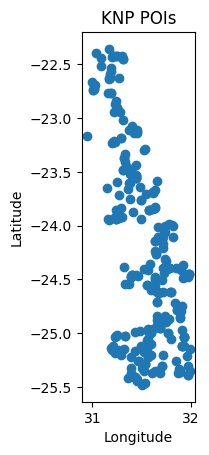

In [288]:
gdf.set_geometry('Geometry', inplace=True, crs='EPSG:4326')
gdf.plot()

plt.title('KNP POIs')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

In [283]:
gdf['Access'].value_counts(dropna=False).rename_axis('Access').reset_index(name='Count')

,Access,Count
0,Public,221
1,Private,54
2,Staff,23


In [284]:
gdf['Type'].value_counts(dropna=False).rename_axis('Type').reset_index(name='Count')

,Type,Count
0,Borehole,79
1,Concession camp,29
2,"Dam, earthen",18
3,Picnic spot,14
4,Bird hide,13
5,Look out point,13
6,Get out point,13
7,Rest camp,12
8,Ranger camp,11
9,Staff Accommodation,11
